In [1]:
from functools import partial

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dynamical_systems.continuous import Lorenz63, solve_ode, AbstractODE
from dynamical_systems.dataset import TimeSeriesDataset
from dynamics_discovery.models import NeuralODE
from jaxtyping import Array, Float
from matplotlib_utils.axes_setters import set_labels

jax.config.update("jax_enable_x64", True)

In [2]:
lorenz = Lorenz63()
dataset_loaded = TimeSeriesDataset.load("./data/lorenz.hdf5")

In [3]:
import diffrax as dfx


def perturbation(
    ode: AbstractODE,
    norm: float = 1e-6,
    n: int = 1,
    key: jax.random.PRNGKey = jax.random.PRNGKey(0),
):
    perturb = jax.random.normal(key, (n, ode.dim))
    return norm * perturb / jnp.linalg.norm(perturb, axis=-1, keepdims=True)


p = perturbation(lorenz, n=100)


@partial(eqx.filter_vmap, in_axes=(0, None, None))
def calculate_perturbation(u0, t_max, dt=0.1):
    t = jnp.arange(0, t_max + dt, dt)
    u = solve_ode(lorenz, t, u0, rtol=1e-6, atol=1e-6, max_steps=4096)
    return u


u_train = dataset_loaded.u[0]
u0_vals = jnp.concatenate((jnp.expand_dims(u_train[0], 0), u_train[0] + p), axis=0)
u_vals = calculate_perturbation(u0_vals, 50.0, 0.1)

In [24]:
def local_predictability(
    ode: AbstractODE,
    u: Float[Array, "time dim"],
    t: Float[Array, " time_perturb"],
    n_perturbs: int = 100,
    perturb_norm: float = 1e-6,
    key: jax.random.PRNGKey = jax.random.PRNGKey(0),
):
    @partial(eqx.filter_vmap, in_axes=(None, 0))
    def _solve_ode(t, u0):
        return solve_ode(ode, t, u0, rtol=1e-6, atol=1e-6, max_steps=4096)

    @eqx.filter_vmap
    def _integrate_perturbation(
        u0: Float[Array, " dim"],
    ) -> Float[Array, "time_perturb dim"]:
        p = perturbation(ode, perturb_norm, n_perturbs, key)
        u0_total: Float[Array, "n_perturbs+1 dim"] = jnp.concatenate(
            (jnp.expand_dims(u0, 0), u0 + p), axis=0
        )
        u_total: Float[Array, "n_perturbs+1 time_perturb dim"] = _solve_ode(t, u0_total)

        error_norm = jnp.mean(
            jnp.linalg.norm(u_total[1:] - u_total[0], axis=-1), axis=0
        )
        lya = jnp.log(error_norm / perturb_norm) / t
        return lya

    return _integrate_perturbation(u)

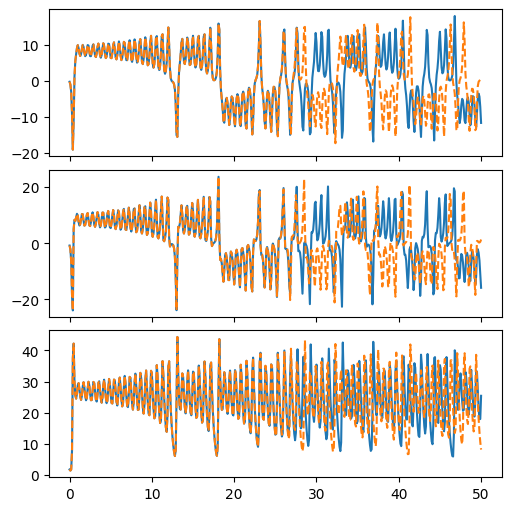

In [5]:
fig, axes = plt.subplots(
    lorenz.dim, 1, figsize=(5, 5), sharex=True, constrained_layout=True
)
ind_sample = 5
t = jnp.arange(u_vals.shape[1]) * 0.1
for i, ax in enumerate(axes):
    ax.plot(t, u_vals[0, :, i], label="Orig")
    ax.plot(t, u_vals[ind_sample, :, i], "--", label="Perturbed")

In [6]:
du = jnp.linalg.norm(u_vals[0] - u_vals[1:], axis=-1)
lya_local = jnp.log(du / 1e-6) / t
lya_local.shape

(100, 501)

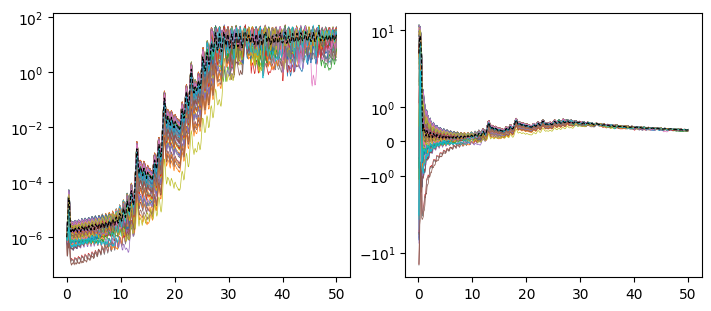

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharex=True, constrained_layout=True)
lya_mean = jnp.mean(lya_local, axis=0)
for lya in lya_local:
    axes[1].plot(t, lya, linewidth=0.5)
axes[1].plot(t, lya_mean, "--", color="black", linewidth=0.8)
axes[1].set_yscale("symlog", base=10)

for du_ in du:
    axes[0].plot(t, du_, linewidth=0.5)
axes[0].plot(t, jnp.mean(du, axis=0), "--", color="black", linewidth=0.8)
axes[0].set_yscale("log", base=10)

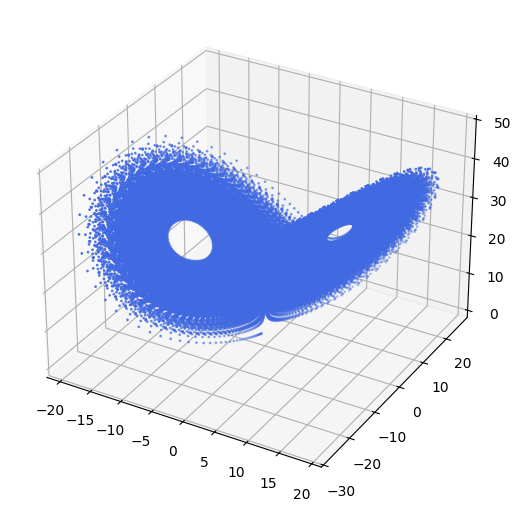

In [94]:
u_train_coarse = u_train[::1,]

fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
ax.scatter(*u_train_coarse.T, ".", s=1, color="royalblue")

In [95]:
t = jnp.arange(30)
lya_local = local_predictability(lorenz, u_train_coarse, t)
lya_mean = jnp.mean(lya_local, axis=0)

2025-03-27 13:48:52.476519: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 15.97GiB (17143248248 bytes) by rematerialization; only reduced to 20.69GiB (22220000112 bytes), down from 20.69GiB (22220000112 bytes) originally


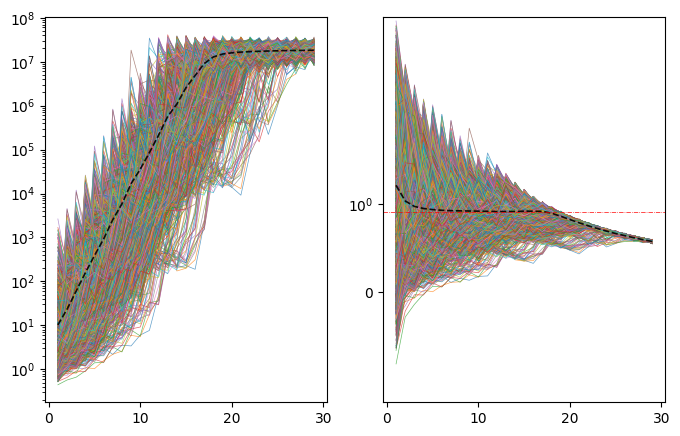

In [162]:
rel_error_norm = jnp.exp(lya_local * t)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True)
for lya_i, err_i in zip(lya_local[::10], rel_error_norm[::10]):
    axes[0].plot(t, err_i, linewidth=0.5, alpha=0.7)
    axes[1].plot(t, lya_i, linewidth=0.5, alpha=0.7)
axes[0].plot(
    t, jnp.mean(rel_error_norm, axis=0), "--", color="black", linewidth=1.2, alpha=0.9
)
axes[1].plot(t, lya_mean, "--", color="black", linewidth=1.2, alpha=0.9)
axes[0].set_yscale("log", base=10)
axes[1].set_yscale("symlog", base=10)
axes[1].axhline(
    y=0.90566,
    color="red",
    linewidth=0.5,
    linestyle="-.",
)


In [ ]:
rel_error_norm.shape

(100000, 30)

In [146]:
jnp.savez("./data/lorenz_local_lyapunov.npz", t=t, lya_local=lya_local)

In [77]:
lya_local[0]

Array([      -inf, 0.6457658 , 0.2152041 , 0.25847287, 0.22643675,
       0.16250884, 0.18723723, 0.11155589, 0.15776289, 0.13605421,
       0.17941554, 0.18515556, 0.32445531, 0.56945527, 0.38196936,
       0.36225917, 0.3274927 , 0.45237081, 0.61225631, 0.51547543,
       0.47708893, 0.43435869, 0.51407334, 0.59890378, 0.51272957,
       0.55190426, 0.59438038, 0.58720361, 0.56056531, 0.57958907,
       0.55254351, 0.50988545, 0.52279275, 0.52033977, 0.47990767,
       0.47790534, 0.46512467, 0.45094625, 0.43573134, 0.42673595,
       0.40664816, 0.40447945, 0.39919812, 0.38150826, 0.37785473,
       0.37821842, 0.35602596, 0.35192826, 0.3511469 , 0.33597471],      dtype=float64)

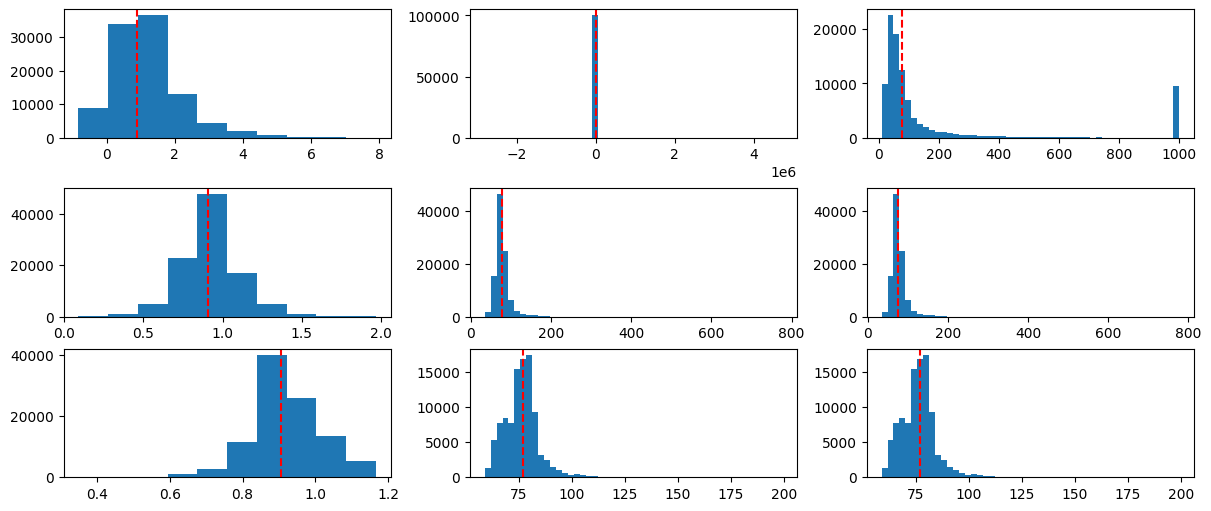

In [126]:
fig, axes = plt.subplots(3, 3, figsize=(12, 5), constrained_layout=True)
inds_time = (1, 7, 15)
for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 0])):
    ax.hist(lya_local[:, ind], bins=10)
    ax.axvline(x=0.90566, linestyle="--", color="red")

dt = dataset_loaded.t[1] - dataset_loaded.t[0]
batch_lengths = jnp.round(jnp.log(2) / (lya_local * dt))

for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 1])):
    ax.hist(batch_lengths[:, ind], bins=50)
    ax.axvline(x=77, linestyle="--", color="red")

MAX_BATCH_LENGTH = 1000
batch_lengths_mod = jnp.clip(batch_lengths, max=MAX_BATCH_LENGTH)
batch_lengths_mod = batch_lengths_mod.at[batch_lengths_mod < 0].set(MAX_BATCH_LENGTH)

for i, (ind, ax) in enumerate(zip(inds_time, axes[:, 2])):
    ax.hist(batch_lengths_mod[:, ind], bins=50)
    ax.axvline(x=77, linestyle="--", color="red")

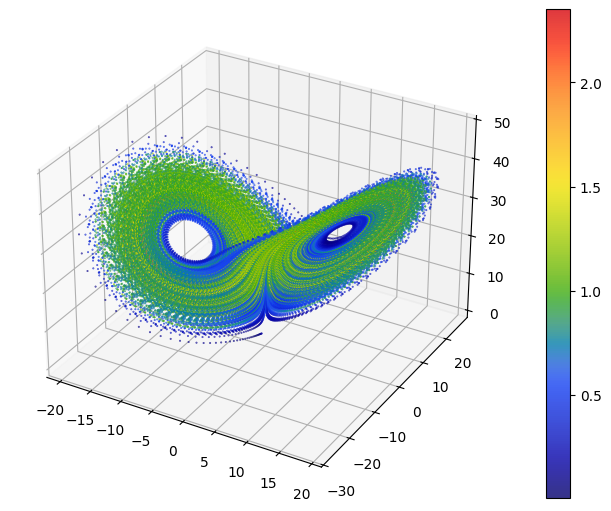

In [150]:
import colorcet as cc

idx_time = 5
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=lya_local[:, idx_time],
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

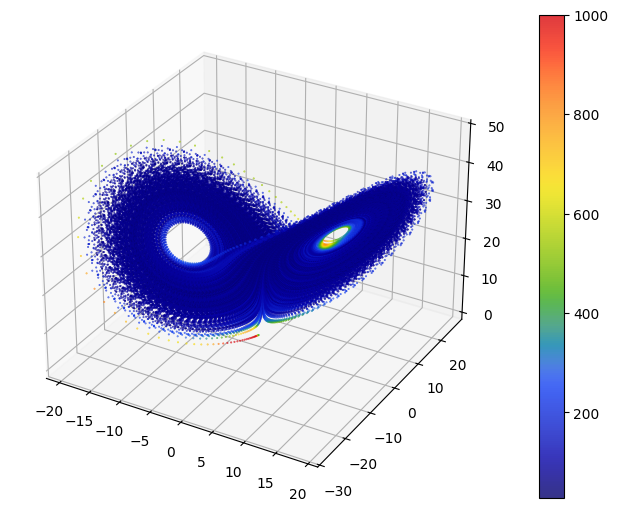

In [151]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=batch_lengths_mod[:, idx_time],
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

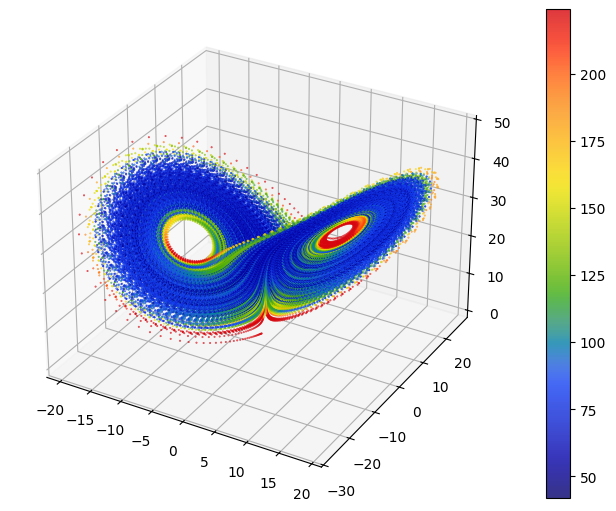

In [152]:
clip_percentile = 1
fig, ax = plt.subplots(
    1, 1, figsize=(8, 5), constrained_layout=True, subplot_kw={"projection": "3d"}
)
batch_lengths_clipped = jnp.clip(
    batch_lengths_mod[:, idx_time],
    min=jnp.percentile(batch_lengths_mod[:, idx_time], clip_percentile),
    max=jnp.percentile(batch_lengths_mod[:, idx_time], 100 - clip_percentile),
)
sc = ax.scatter(
    *u_train_coarse.T,
    ".",
    c=batch_lengths_clipped,
    s=0.2,
    alpha=0.8,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(sc)

In [157]:
batch_len_sorted = jnp.sort(batch_lengths_clipped)
batch_len_gap = jnp.unique(batch_len_sorted[1:] - batch_len_sorted[0:-1])

In [158]:
batch_len_gap

Array([0., 1.], dtype=float64)